# Análisis Exploratorio de Datos

## 1. Importación de librerías y carga de datos.

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings

# Configuración de warnings y pandas.
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Estilo global de gráficos.
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print(f'Librerías cargadas correctamente.')

Librerías cargadas correctamente.


In [4]:
ruta = './data/GAP_clean.csv'
df = pd.read_csv(ruta)
print(f'Dataset cargado correctamente!')
print(f'Numero de filas: {df.shape[0]} | Numero de columnas: {df.shape[1]}')
df.head()

Dataset cargado correctamente!
Numero de filas: 8000 | Numero de columnas: 16


,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades,risk_flag,gaming_intensity
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.46,0,Extremo (6-8h)
1,2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.23,0,Minimo (0-1h)
2,3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.56,0,Moderado (1-3h)
3,4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.67,1,Extremo (6-8h)
4,5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.71,0,Intenso (3-6h)


Al cargar de nuevo el dataset, se convierte en tipo object. Por tanto, hay que restaurar los tipos de nuevo.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        8000 non-null   int64  
 1   age               8000 non-null   int64  
 2   gender            8000 non-null   object 
 3   gaming_hours      8000 non-null   float64
 4   study_hours       8000 non-null   float64
 5   sleep_hours       8000 non-null   float64
 6   attendance        8000 non-null   float64
 7   gaming_genre      8000 non-null   object 
 8   social_activity   8000 non-null   float64
 9   device_usage      8000 non-null   float64
 10  reaction_time_ms  8000 non-null   float64
 11  addiction_score   8000 non-null   float64
 12  stress_level      8000 non-null   object 
 13  grades            8000 non-null   float64
 14  risk_flag         8000 non-null   int64  
 15  gaming_intensity  8000 non-null   object 
dtypes: float64(9), int64(3), object(4)
memory 

In [6]:
# Restaurar el tipo ordinal de stress_level tras la carga.
stress_order = pd.CategoricalDtype(categories=['Low', 'Medium', 'High'], ordered=True)
df['stress_level'] = df['stress_level'].astype(stress_order)

# Restaurar gaming_intensity como categoría ordenada.
intensity_order = pd.CategoricalDtype(
    categories=['Mínimo (0-1h)', 'Moderado (1-3h)','Intenso(3-6h)','Extremo (6-8h)'], 
    ordered=True
)
df['gaming_intensity'] = df['gaming_intensity'].astype(intensity_order)

print(f'Cambios realizados correctamente!')


Cambios realizados correctamente!


## 2. Distribuciones univariadas

El objetivo es entender cada variable por separado antes de cruzarlas, de esta forma obtenemos más información sobre la naturaleza real de los datos.

Comenzaremos por investigar la distribución de las variables numéricas continuas.

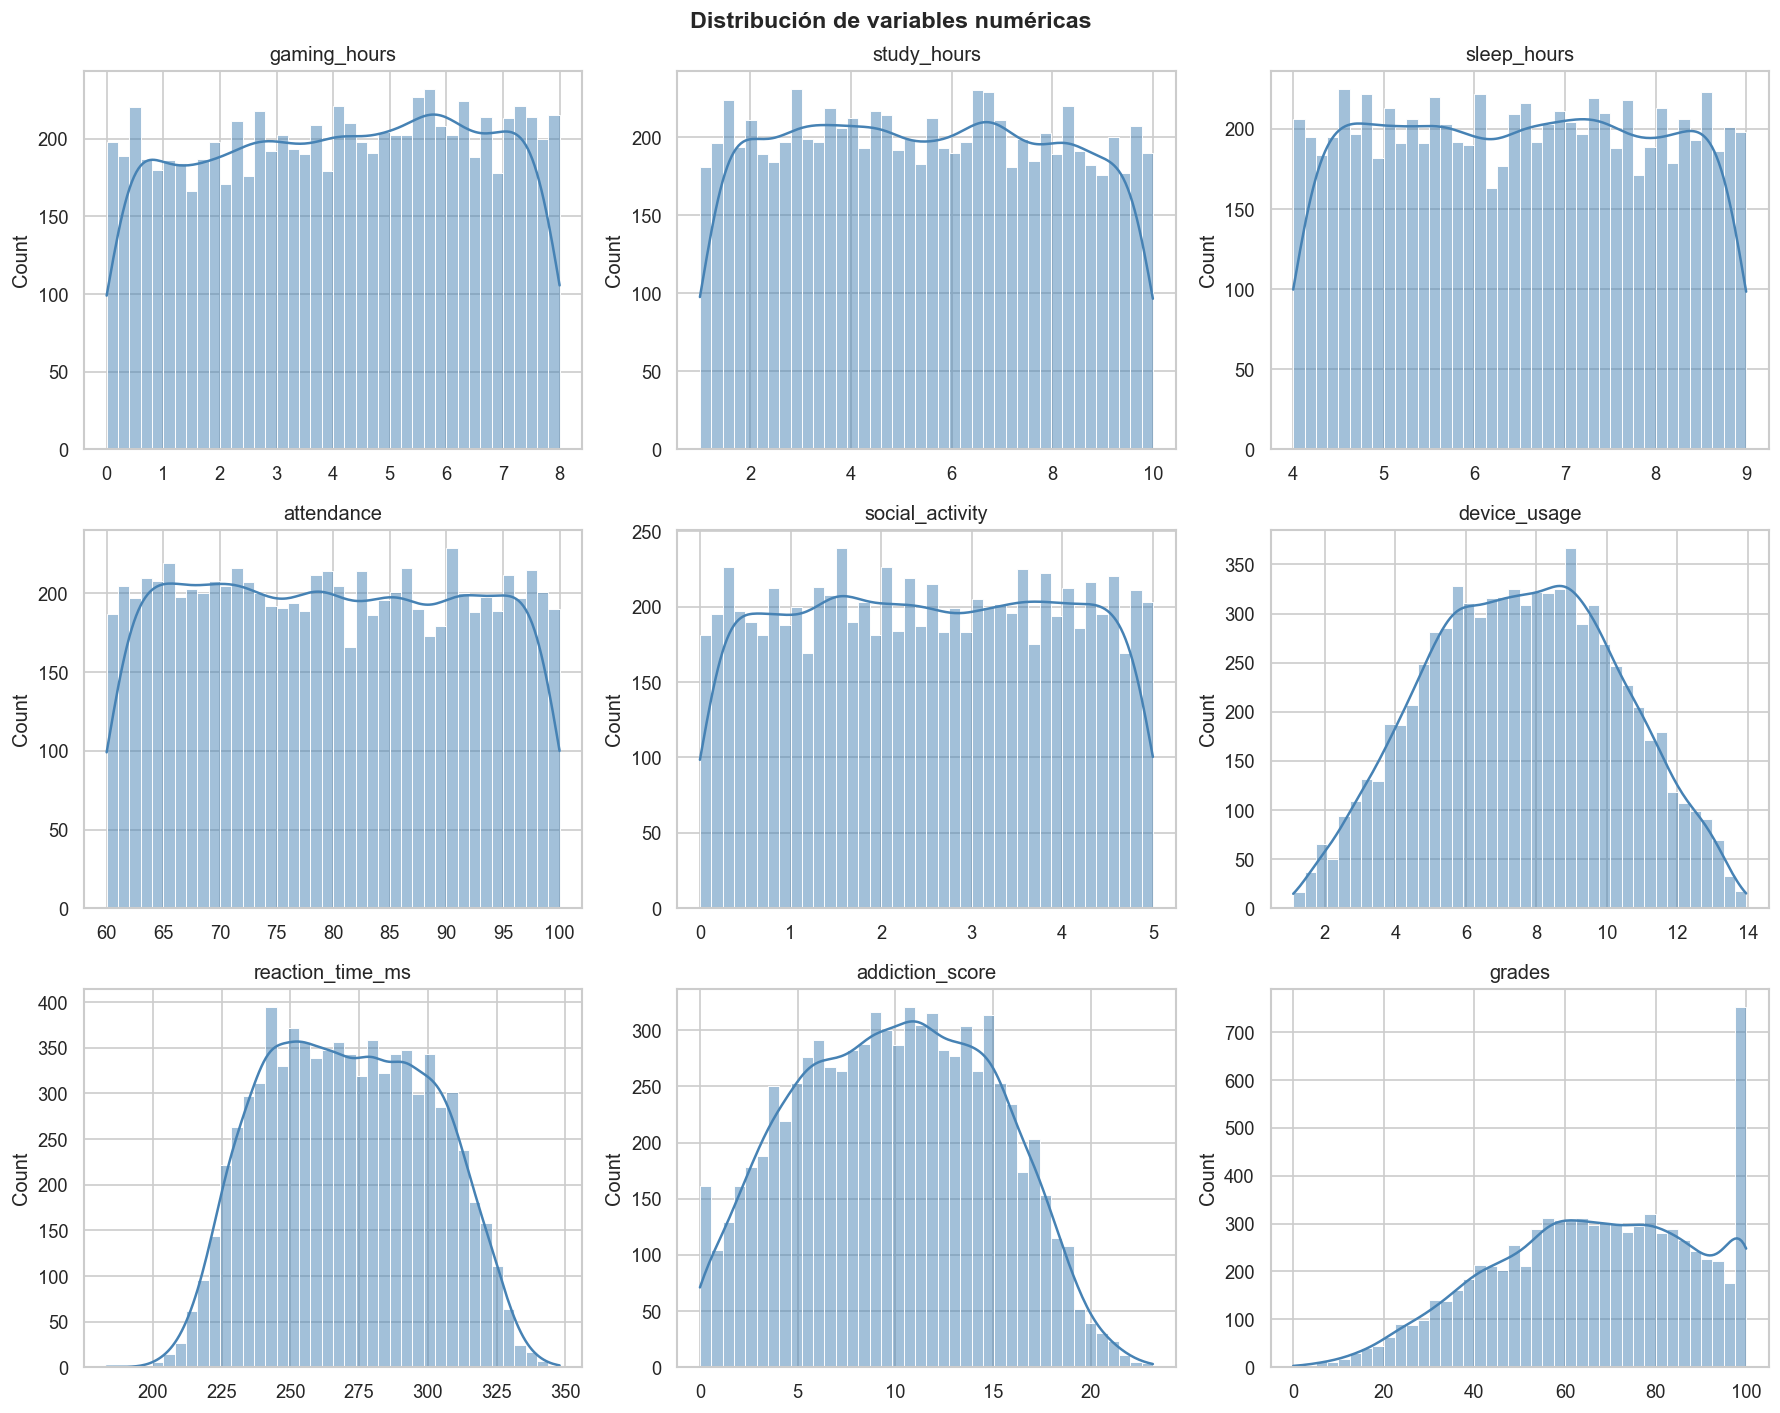

In [7]:
# Escogemos las variables númericas para el análisis.
num_cols = ['gaming_hours', 'study_hours', 'sleep_hours', 'attendance',
            'social_activity', 'device_usage', 'reaction_time_ms', 
            'addiction_score', 'grades']

# Configuramos el gráfico para mostrar las distribuciones.
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
fig.suptitle('Distribución de variables numéricas', fontsize=14, fontweight='bold')

# Iteramos sobre las variables y ejes para crear histogramas.
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], bins=40, kde=True, ax=ax, color='steelblue')
    ax.set_title(col)
    ax.set_xlabel('')

# Guardar y mostrar el gráfico.
plt.tight_layout()
plt.savefig('./img/fig_distribuciones_numericas.png', dpi=120, bbox_inches='tight')
plt.show()


La mayoría son distribuciones normales (o Gaussianas) a excepción de addiction score, que está sesgada a la derecha, y grades, que se encuentra sesgada a la izquierda.

Son datos interesantes ya que 'addiction_score' muestran que los valores más altos son muy poco comunes. Al contrario que en 'grades', que las puntuaciones más bajas no están.